In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
import plotly.figure_factory as ff

In [2]:
df = pd.read_csv('climatechange.csv')

In [3]:
df

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS Code,CTS Name,CTS Full Descriptor,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,1,"Afghanistan, Islamic Rep. of",AF,AFG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.139,1.588,1.630,1.597,0.951,0.552,1.418,1.967,1.748,2.188
1,2,Africa,NaN,AFRTMP,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.195,1.385,1.158,1.150,1.290,1.177,1.400,1.014,1.485,1.750
2,3,Albania,AL,ALB,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.702,1.608,1.239,2.155,1.797,1.627,1.719,1.701,2.299,2.925
3,4,Algeria,DZ,DZA,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.134,1.761,1.506,1.203,1.240,2.006,2.424,1.804,2.303,2.824
4,5,American Samoa,AS,ASM,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,0.738,1.268,1.163,0.917,1.268,1.159,0.997,0.984,1.010,1.588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,232,Western Sahara,EH,ESH,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.530,1.610,2.043,0.974,1.559,2.145,1.674,2.041,2.442,2.232
227,233,World,NaN,WLD,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.412,1.693,1.433,1.253,1.440,1.675,1.485,1.389,1.778,2.118
228,234,"Yemen, Rep. of",YE,YEM,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
229,235,Zambia,ZM,ZMB,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.874,1.428,0.568,0.825,1.287,1.217,1.183,0.859,1.277,1.644


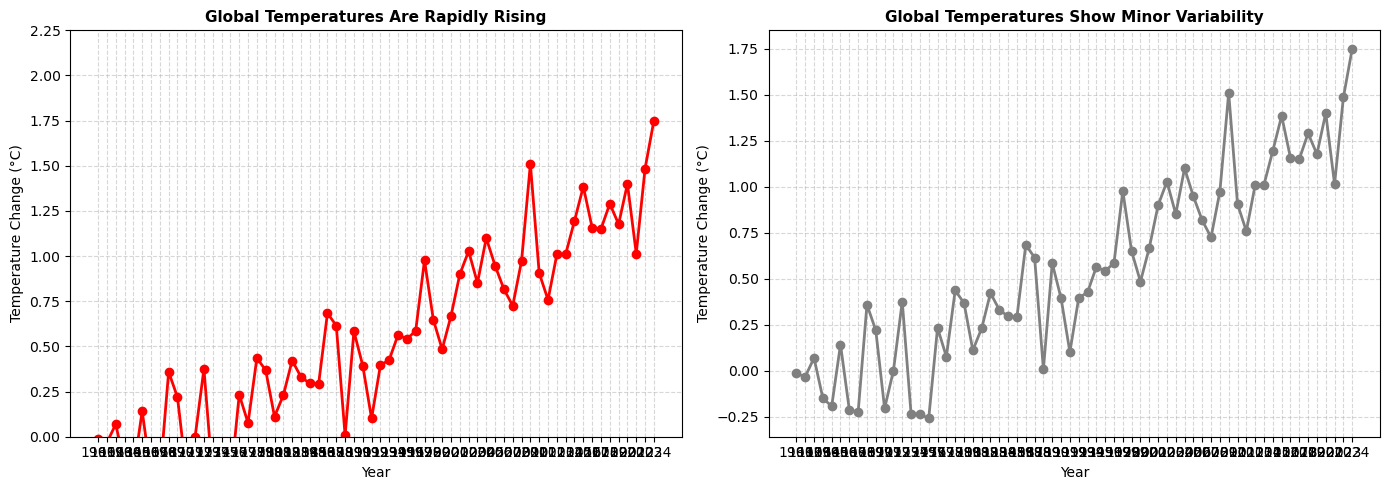

In [4]:
global_row = df.iloc[1]

# Extract year columns and convert to float
years = df.columns[10:]
temperatures = global_row[10:].astype(float)

# Create two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Visualization 1: Earnest (shows clear rise)
ax1.plot(years, temperatures, marker='o', color='red', linewidth=2)
ax1.set_title('Global Temperatures Are Rapidly Rising', fontsize=11, weight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Temperature Change (°C)')
ax1.set_ylim(0, max(temperatures) + 0.5)
ax1.grid(True, linestyle='--', alpha=0.5)

# Visualization 2: Deceptive (flattens the trend)
ax2.plot(years, temperatures, marker='o', color='gray', linewidth=2)
ax2.set_title('Global Temperatures Show Minor Variability', fontsize=11, weight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Temperature Change (°C)')
ax2.set_ylim(min(temperatures) - 0.1, max(temperatures) + 0.1)  # artificially narrow y-axis
ax2.grid(True, linestyle='--', alpha=0.5)

# Layout adjustment
plt.tight_layout()
plt.show()

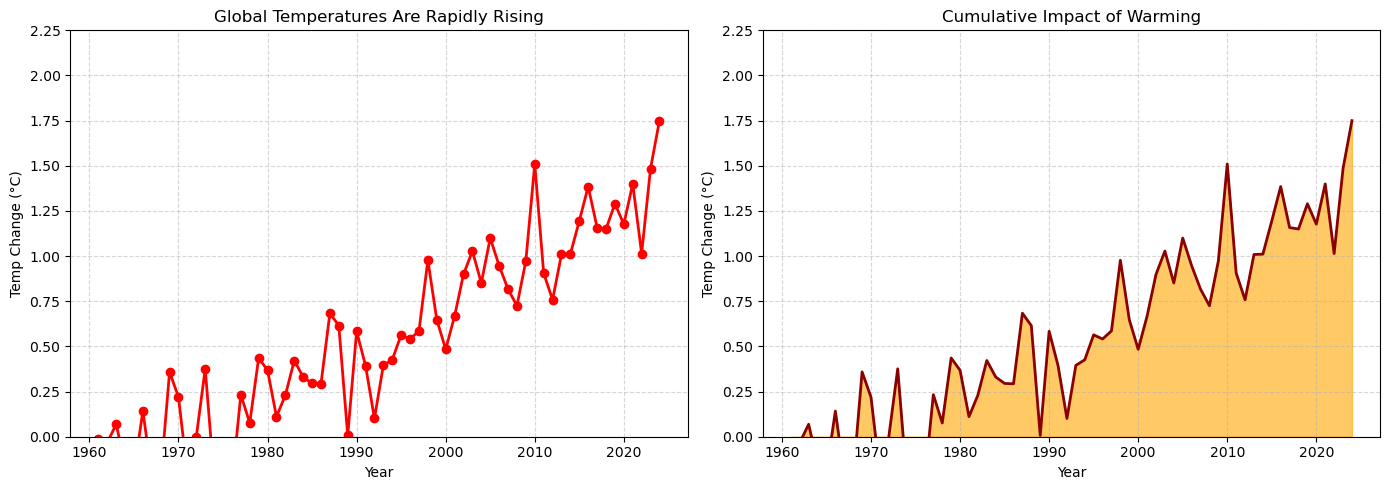

In [5]:
# Convert both years and temps to NumPy float arrays
years_clean = pd.to_numeric(years, errors='coerce').to_numpy(dtype=float)
temps_clean = pd.to_numeric(temperatures, errors='coerce').to_numpy(dtype=float)

# Filter out any NaN values
valid_indices = ~((pd.isna(years_clean)) | (pd.isna(temps_clean)))
years_clean = years_clean[valid_indices]
temps_clean = temps_clean[valid_indices]

# Generate the two earnest visualizations for Page 1
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Line chart
ax1.plot(years_clean, temps_clean, color='red', linewidth=2, marker='o')
ax1.set_title('Global Temperatures Are Rapidly Rising')
ax1.set_xlabel('Year')
ax1.set_ylabel('Temp Change (°C)')
ax1.set_ylim(0, temps_clean.max() + 0.5)
ax1.grid(True, linestyle='--', alpha=0.5)

# Area chart
ax2.fill_between(years_clean, temps_clean, color='orange', alpha=0.6)
ax2.plot(years_clean, temps_clean, color='darkred', linewidth=2)
ax2.set_title('Cumulative Impact of Warming')
ax2.set_xlabel('Year')
ax2.set_ylabel('Temp Change (°C)')
ax2.set_ylim(0, temps_clean.max() + 0.5)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()



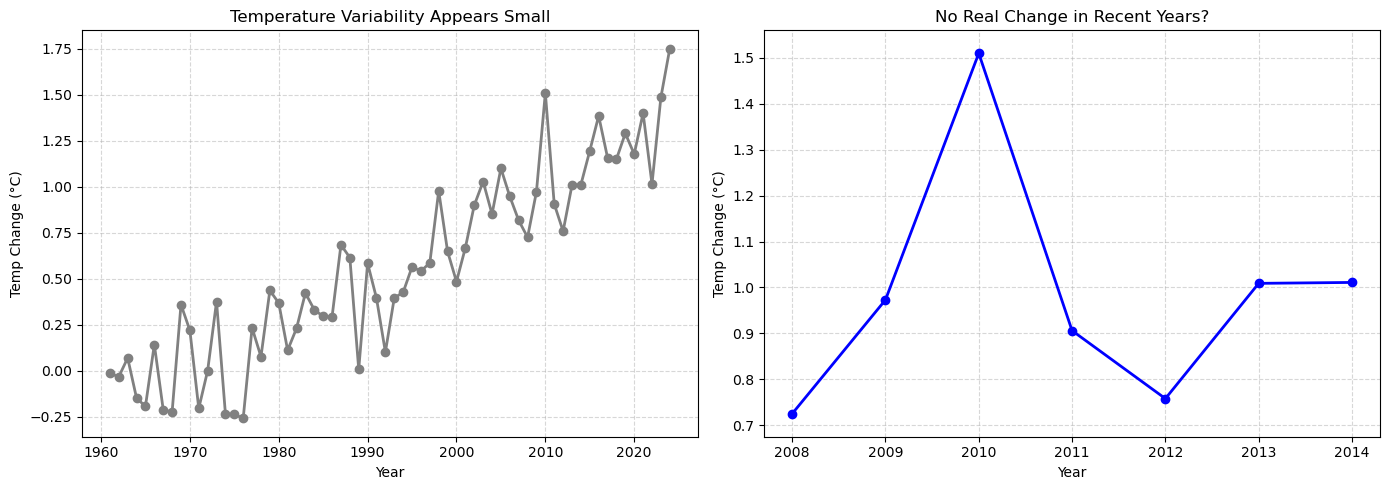

In [6]:
# Generate two deceptive visualizations for Page 2

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Deceptive Plot 1: Truncated Y-axis
ax1.plot(years_clean, temps_clean, color='gray', linewidth=2, marker='o')
ax1.set_title('Temperature Variability Appears Small')
ax1.set_xlabel('Year')
ax1.set_ylabel('Temp Change (°C)')
ax1.set_ylim(temps_clean.min() - 0.1, temps_clean.max() + 0.1)
ax1.grid(True, linestyle='--', alpha=0.5)

# Deceptive Plot 2: Cherry-picked years (2008–2014)
mask = (years_clean >= 2008) & (years_clean <= 2014)
subset_years = years_clean[mask]
subset_temps = temps_clean[mask]

ax2.plot(subset_years, subset_temps, color='blue', marker='o', linewidth=2)
ax2.set_title('No Real Change in Recent Years?')
ax2.set_xlabel('Year')
ax2.set_ylabel('Temp Change (°C)')
ax2.set_ylim(subset_temps.min() - 0.05, subset_temps.max() + 0.05)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()


In [ ]:
df.columns

Index(['ObjectId', 'Country', 'ISO2', 'ISO3', 'Indicator', 'Unit', 'Source',
       'CTS Code', 'CTS Name', 'CTS Full Descriptor', '1961', '1962', '1963',
       '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972',
       '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981',
       '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990',
       '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999',
       '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
       '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2018', '2019', '2020', '2021', '2022', '2023', '2024'],
      dtype='object')

In [ ]:
df['ISO2']

0       AF
1      NaN
2       AL
3       DZ
4       AS
      ... 
226     EH
227    NaN
228     YE
229     ZM
230     ZW
Name: ISO2, Length: 231, dtype: object

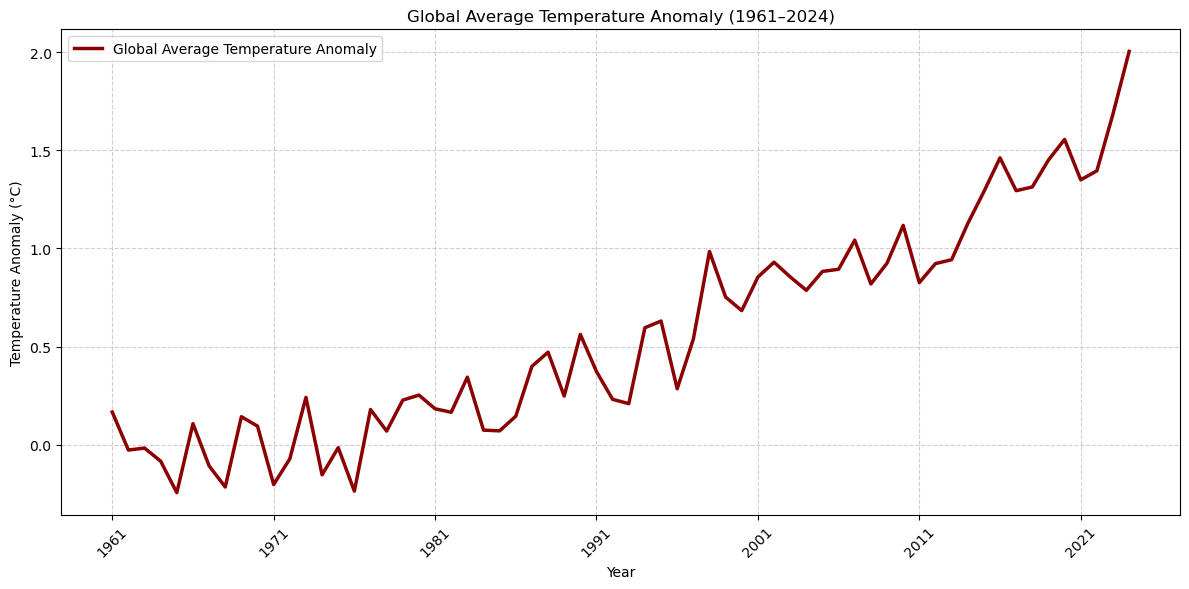

In [ ]:
# Compute the global average temperature anomaly for all years
global_avg_temp_all_years = df[years].mean()

# Plot a simple line plot of global temperature anomaly over the years
plt.figure(figsize=(12, 6))
plt.plot(global_avg_temp_all_years.index, global_avg_temp_all_years.values,
         label='Global Average Temperature Anomaly', linewidth=2.5, color='darkred')

plt.title('Global Average Temperature Anomaly (1961–2024)')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.xticks([str(y) for y in range(1961, 2025, 10)], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


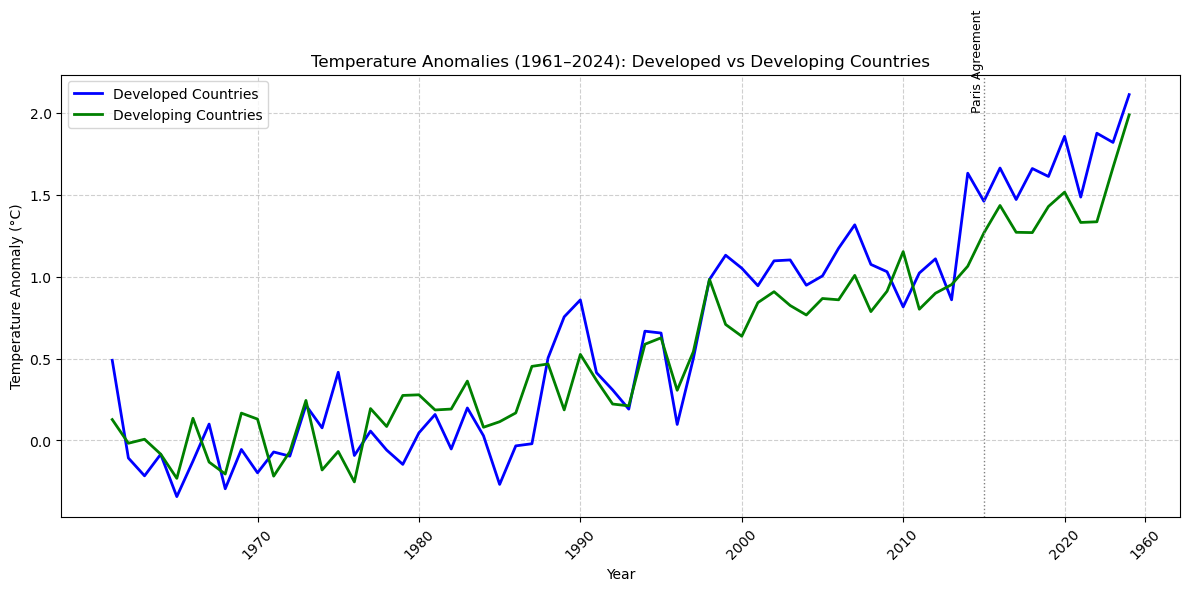

In [ ]:
# Updated group classification using World Bank's 2024–2025 income classification logic
# Source: https://blogs.worldbank.org/en/opendata/world-bank-country-classifications-by-income-level-for-2024-2025
# Define "Developed" as High-income economies, others as "Developing"

high_income_countries = {
    'United States', 'Canada', 'Germany', 'France', 'United Kingdom', 'Japan', 'Australia',
    'South Korea', 'Norway', 'Sweden', 'Switzerland', 'Netherlands', 'Finland', 'Denmark',
    'Ireland', 'Singapore', 'New Zealand', 'Belgium', 'Austria', 'Luxembourg', 'Iceland',
    'Czech Republic', 'Estonia', 'Slovenia', 'Israel', 'United Arab Emirates', 'Qatar',
    'Saudi Arabia', 'Kuwait', 'Brunei', 'Hong Kong SAR, China'
}

# Classify countries based on World Bank rule
df['DevGroup'] = df['Country'].apply(
    lambda x: 'Developed' if x in high_income_countries else 'Developing'
)

# Group by development group and compute average temperature anomaly per year
dev_group_avg = df.groupby('DevGroup')[years].mean()

# Global average for all countries
global_avg = df[years].mean()

# Plot
plt.figure(figsize=(12, 6))


plt.plot(dev_group_avg.columns, dev_group_avg.loc['Developed'], label='Developed Countries',
         linewidth=2, linestyle='-', color='blue')
plt.plot(dev_group_avg.columns, dev_group_avg.loc['Developing'], label='Developing Countries',
         linewidth=2, linestyle='-', color='green')

# Annotate key climate agreement
plt.axvline('2015', color='gray', linestyle=':', linewidth=1)
plt.text('2015', global_avg.max(), 'Paris Agreement', rotation=90, va='bottom', ha='right', fontsize=9)

plt.title('Temperature Anomalies (1961–2024): Developed vs Developing Countries')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.xticks([str(y) for y in range(1960, 2025, 10)], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/p4/4sw9swv12vd7n6f5q9xx9znh0000gn/T/ipykernel_38490/778555725.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


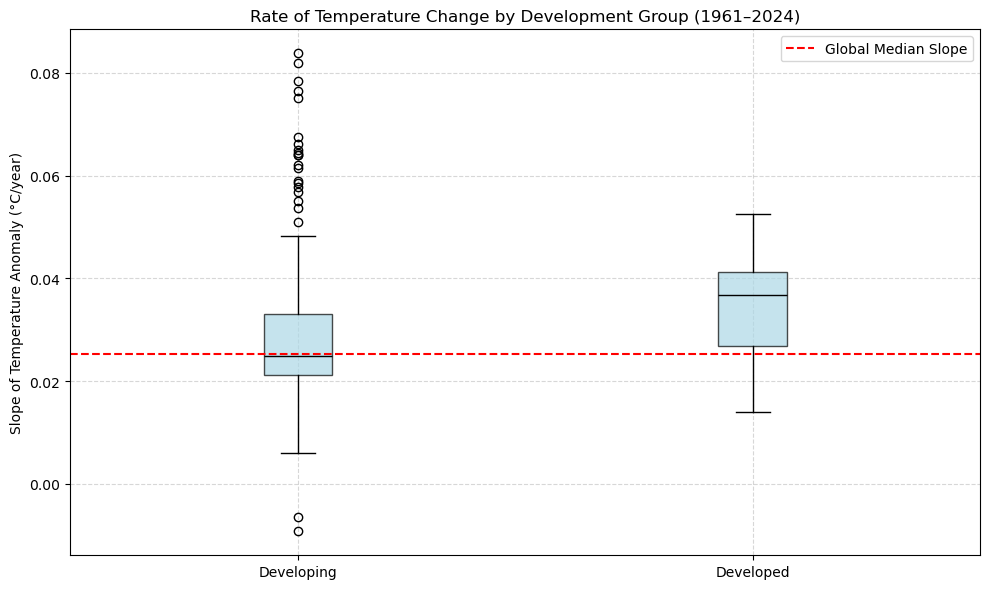

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np
filtered_df = df.copy()
# 1. Create list of years as strings
years = [str(y) for y in range(1961, 2025)]

# 2. Define developed countries based on World Bank high-income classification
high_income_countries = { 'United States', 'Canada', 'Germany', 'France', 'United Kingdom',
    'Japan', 'Australia', 'South Korea', 'Sweden', 'Norway', 'Switzerland', 'Netherlands', 'Finland',
    'Denmark', 'Ireland', 'Singapore', 'New Zealand', 'Belgium', 'Austria', 'Luxembourg', 'Iceland',
    'Czech Republic', 'Estonia', 'Slovenia', 'Israel', 'United Arab Emirates', 'Qatar', 'Saudi Arabia',
    'Kuwait', 'Brunei', 'Hong Kong SAR, China' }

# 3. Assign development group
filtered_df['DevGroup'] = filtered_df['Country'].apply(lambda x: 'Developed' if x in high_income_countries else 'Developing')

# 4. Calculate slope (rate of temperature change) for each country
def calc_slope(row):
    x = np.array([int(y) for y in years])
    y = row[years].values.astype(float)
    mask = ~np.isnan(y)
    if mask.sum() > 1:
        slope, _, _, _, _ = linregress(x[mask], y[mask])
        return slope
    return np.nan

filtered_df['Slope'] = filtered_df.apply(calc_slope, axis=1)

# 5. Filter valid rows and plot
plot_df = filtered_df[filtered_df['Slope'].notna()]

# 6. Boxplot comparing slope (warming rate) by development group
plt.figure(figsize=(10, 6))
plt.boxplot(
    [plot_df[plot_df['DevGroup'] == group]['Slope'] for group in ['Developing', 'Developed']],
    labels=['Developing', 'Developed'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', alpha=0.7),
    medianprops=dict(color='black')
)

plt.axhline(plot_df['Slope'].median(), color='red', linestyle='--', label='Global Median Slope')
plt.title("Rate of Temperature Change by Development Group (1961–2024)")
plt.ylabel("Slope of Temperature Anomaly (°C/year)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


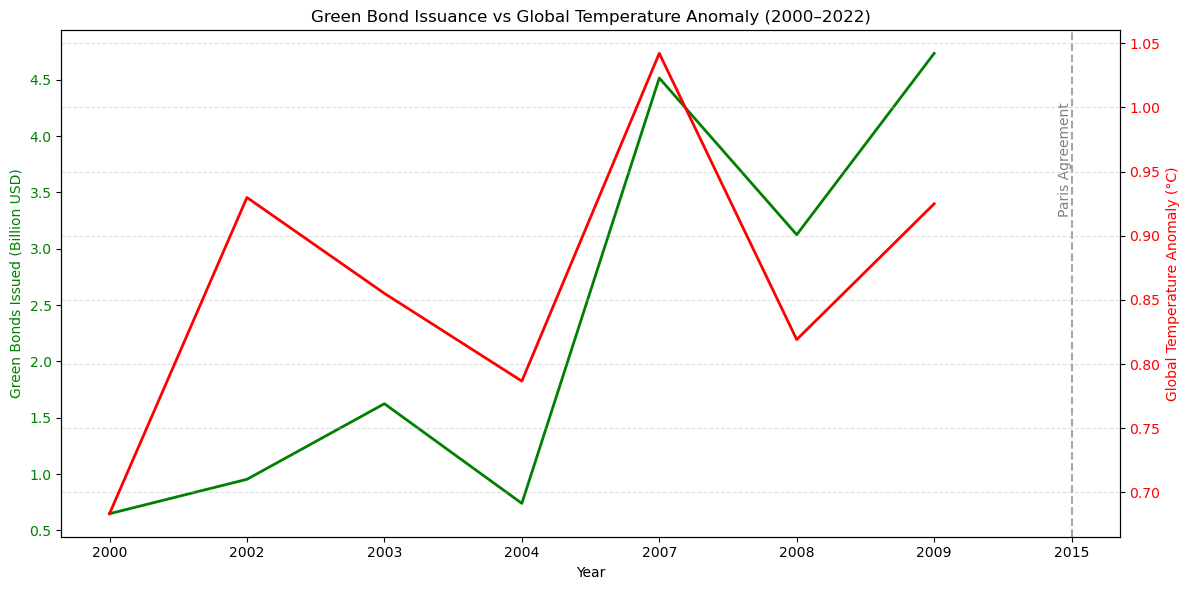

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load datasets

green_bond_df = pd.read_csv('Green_Bonds.csv')

# Step 2: Create global average temperature anomaly per year
years = [str(y) for y in range(1961, 2025)]
temp_by_year = df[years].mean()

# Step 3: Sum global green bond issuance per year
green_bond_years_filtered = [col for col in green_bond_df.columns if col.startswith('F200')]
green_bonds_yearly_total = green_bond_df[green_bond_years_filtered].sum()

# Clean up year format
green_bonds_yearly_total.index = green_bonds_yearly_total.index.str[1:]  # Remove 'F'
green_bonds_yearly_total = green_bonds_yearly_total.astype(float)

# Step 4: Fix type mismatch between indexes
green_bonds_yearly_total.index = green_bonds_yearly_total.index.astype(str)
temp_by_year.index = temp_by_year.index.astype(str)

# Step 5: Match overlapping years
temp_anomaly_years = [y for y in green_bonds_yearly_total.index if y in temp_by_year.index]
green_bonds_values = green_bonds_yearly_total[temp_anomaly_years]
temp_anomaly_values = temp_by_year[temp_anomaly_years]

# Step 6: Dual-axis plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot green bonds (left axis)
ax1.set_xlabel('Year')
ax1.set_ylabel('Green Bonds Issued (Billion USD)', color='green')
ax1.plot(green_bonds_values.index, green_bonds_values.values, color='green', label='Green Bonds Issued', linewidth=2)
ax1.tick_params(axis='y', labelcolor='green')

# Plot temperature anomaly (right axis)
ax2 = ax1.twinx()
ax2.set_ylabel('Global Temperature Anomaly (°C)', color='red')
ax2.plot(temp_anomaly_values.index, temp_anomaly_values.values, color='red', label='Temperature Anomaly', linewidth=2)
ax2.tick_params(axis='y', labelcolor='red')

# Add Paris Agreement annotation
ax1.axvline('2015', linestyle='--', color='gray', alpha=0.7)
ax1.text('2015', max(green_bonds_values) * 0.8, 'Paris Agreement', rotation=90, color='gray', ha='right', va='center')

# Title and grid
plt.title('Green Bond Issuance vs Global Temperature Anomaly (2000–2022)')
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


In [25]:
temp_by_year

1961    0.166804
1962   -0.026770
1963   -0.016667
1964   -0.083521
1965   -0.243753
          ...   
2020    1.554845
2021    1.349059
2022    1.395140
2023    1.685119
2024    2.003201
Length: 64, dtype: float64

In [39]:
# Reload all necessary uploaded files
climate_df = pd.read_csv("climatechange.csv")  # surface temp data
disasters_df = pd.read_csv("climatedisaster.csv")
green_bond_df = pd.read_csv("Green_Bonds.csv")
env_tax_df = pd.read_csv("envprotect.csv")

# Step 1: Compute average green bond issuance by country
green_bond_years = [col for col in green_bond_df.columns if col.startswith('F')]
green_bond_df['Total_Green_Bonds'] = green_bond_df[green_bond_years].sum(axis=1)
green_bond_summary = green_bond_df[green_bond_df['Indicator'].str.contains("Green Bond Issuances by Country", case=False)]
green_bond_summary = green_bond_summary[['Country', 'ISO3', 'Total_Green_Bonds']]

# Step 2: Compute average environmental tax by country (percent of GDP)
env_tax_years = [str(y) for y in range(1995, 2022)]
env_tax_summary = env_tax_df[
    (env_tax_df['Indicator'] == 'Environmental Taxes') &
    (env_tax_df['Unit'] == 'Percent of GDP')
].copy()
env_tax_summary['Avg_Env_Tax'] = env_tax_summary[env_tax_years].mean(axis=1)
env_tax_summary = env_tax_summary[['Country', 'ISO3', 'Avg_Env_Tax']]

# Step 3: Compute average annual disasters per country
disaster_years = [str(y) for y in range(1980, 2025)]
disasters_df['Avg_Disasters'] = disasters_df[disaster_years].mean(axis=1)
disaster_summary = disasters_df[['Country', 'ISO3', 'Avg_Disasters']]

# Step 4: Compute temperature anomaly slope per country
years = [str(y) for y in range(1961, 2025)]
def compute_slope(row):
    x = np.array([int(y) for y in years])
    y = row[years].values.astype(float)
    mask = ~np.isnan(y)
    return linregress(x[mask], y[mask]).slope if mask.sum() > 1 else np.nan

climate_df['Temp_Change_Rate'] = climate_df.apply(compute_slope, axis=1)
temp_summary = climate_df[['Country', 'ISO3', 'Temp_Change_Rate']]

# Step 5: Merge all summaries on ISO3
merged_df = temp_summary.merge(disaster_summary, on='ISO3', how='inner')
merged_df = merged_df.merge(green_bond_summary, on='ISO3', how='left')
env_tax_summary = env_tax_summary.drop(columns=['Country'])  # Drop duplicate country label
merged_df = merged_df.merge(env_tax_summary, on='ISO3', how='left')


# Final selection for correlation matrix
merged_df = merged_df[['Country_x', 'ISO3', 'Temp_Change_Rate', 'Avg_Disasters', 'Total_Green_Bonds', 'Avg_Env_Tax']]
merged_df = merged_df.rename(columns={'Country_x': 'Country'})

merged_df



,Country,ISO3,Temp_Change_Rate,Avg_Disasters,Total_Green_Bonds,Avg_Env_Tax
0,"Afghanistan, Islamic Rep. of",AFG,0.029768,1.000000e+00,NaN,NaN
1,"Afghanistan, Islamic Rep. of",AFG,0.029768,1.125000e+00,NaN,NaN
2,"Afghanistan, Islamic Rep. of",AFG,0.029768,3.250000e+00,NaN,NaN
3,"Afghanistan, Islamic Rep. of",AFG,0.029768,1.526316e+00,NaN,NaN
4,"Afghanistan, Islamic Rep. of",AFG,0.029768,1.285714e+00,NaN,NaN
...,...,...,...,...,...,...
1867,Zimbabwe,ZWE,0.014820,1.684211e+00,NaN,NaN
1868,Zimbabwe,ZWE,0.014820,3.379012e+06,NaN,NaN
1869,Zimbabwe,ZWE,0.014820,3.130200e+04,NaN,NaN
1870,Zimbabwe,ZWE,0.014820,4.345378e+04,NaN,NaN


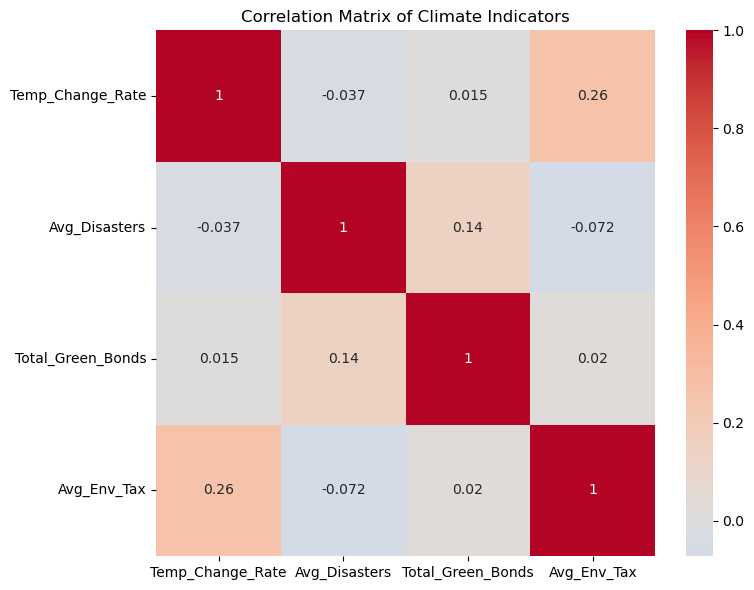

In [40]:
corr_matrix = merged_df[['Temp_Change_Rate', 'Avg_Disasters', 'Total_Green_Bonds', 'Avg_Env_Tax']].corr()

# Plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Climate Indicators')
plt.tight_layout()
plt.show()

In [44]:
filtered_df

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS Code,CTS Name,CTS Full Descriptor,...,2017,2018,2019,2020,2021,2022,2023,2024,DevGroup,Slope
0,1,"Afghanistan, Islamic Rep. of",AF,AFG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.630,1.597,0.951,0.552,1.418,1.967,1.748,2.188,Developing,0.029768
1,2,Africa,NaN,AFRTMP,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.158,1.150,1.290,1.177,1.400,1.014,1.485,1.750,Developing,0.025135
2,3,Albania,AL,ALB,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.239,2.155,1.797,1.627,1.719,1.701,2.299,2.925,Developing,0.034947
3,4,Algeria,DZ,DZA,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.506,1.203,1.240,2.006,2.424,1.804,2.303,2.824,Developing,0.036331
4,5,American Samoa,AS,ASM,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.163,0.917,1.268,1.159,0.997,0.984,1.010,1.588,Developing,0.022167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,232,Western Sahara,EH,ESH,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,2.043,0.974,1.559,2.145,1.674,2.041,2.442,2.232,Developing,0.035375
227,233,World,NaN,WLD,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.433,1.253,1.440,1.675,1.485,1.389,1.778,2.118,Developing,0.029566
228,234,"Yemen, Rep. of",YE,YEM,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Developing,0.011626
229,235,Zambia,ZM,ZMB,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,0.568,0.825,1.287,1.217,1.183,0.859,1.277,1.644,Developing,0.023012
